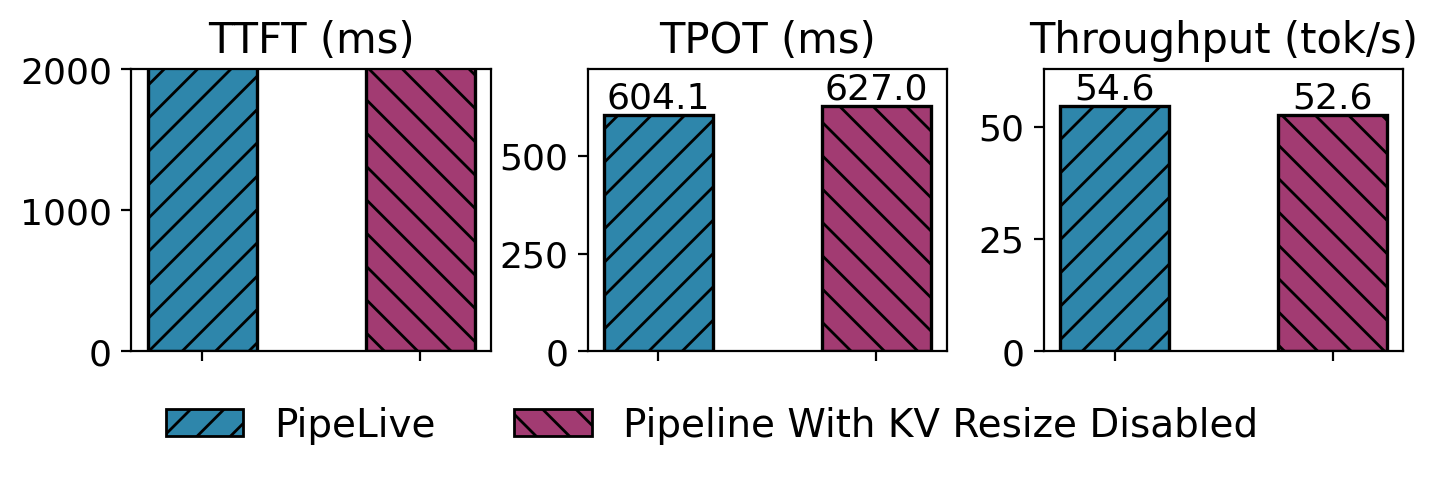

=== 性能指标对比 ===

kv_resize=0:
  TTFT (ms): 4609.16
  TPOT (ms): 627.03
  Throughput (tok/s): 52.63

kv_resize=1:
  TTFT (ms): 4165.39
  TPOT (ms): 604.07
  Throughput (tok/s): 54.63


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# 确保PDF使用矢量字体
plt.rcParams['pdf.fonttype'] = 42  # TrueType字体，放大不模糊
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['figure.dpi'] = 200  # 提升notebook内显示分辨率

# 数据路径
BASE_DIR = "/home/bxb1/vllm_workbench/vllm/new-logs/project-resize-test"
resize_0 = f"{BASE_DIR}/test-{{kernel=direct}}-{{pp=36-44}}-{{rr=1}}-{{mig=1}}-{{in=512}}-{{out=16}}-{{n_req=200}}-{{rep=1}}-{{chunk=5}}-{{mig_mode=async}}-{{blk=128}}-{{vmm=1}}-{{kv_resize=0}}/request_metrics.csv"
resize_1 = f"{BASE_DIR}/test-{{kernel=direct}}-{{pp=36-44}}-{{rr=1}}-{{mig=1}}-{{in=512}}-{{out=16}}-{{n_req=200}}-{{rep=1}}-{{chunk=5}}-{{mig_mode=async}}-{{blk=128}}-{{vmm=1}}-{{kv_resize=1}}/request_metrics.csv"

# 读取数据
df0 = pd.read_csv(resize_0)
df1 = pd.read_csv(resize_1)

# 计算平均指标 (单位转换：秒 -> 毫秒)
input_tokens = 512   # in=512
output_tokens = 16   # out=16
total_tokens = input_tokens + output_tokens  # Total tokens per request

metrics = {
    'kv_resize=0': {
        'TTFT (ms)': df0['ttfts'].mean() * 1000,
        'TPOT (ms)': df0['e2els'].mean() / output_tokens * 1000,
        'Throughput (tok/s)': total_tokens / df0['e2els'].mean()
    },
    'kv_resize=1': {
        'TTFT (ms)': df1['ttfts'].mean() * 1000,
        'TPOT (ms)': df1['e2els'].mean() / output_tokens * 1000,
        'Throughput (tok/s)': total_tokens / df1['e2els'].mean()
    }
}

# 绘制柱状图 - 更紧凑
fig, axes = plt.subplots(1, 3, figsize=(7, 2))
metric_names = ['TTFT (ms)', 'TPOT (ms)', 'Throughput (tok/s)']
colors = ['#2E86AB', '#A23B72']
hatches = ['//', '\\\\']  # 不同的图案
labels = ['PipeLive', 'Pipeline With KV Resize Disabled']
x = np.arange(len(labels))
bar_width = 0.5

for i, metric in enumerate(metric_names):
    values = [metrics['kv_resize=1'][metric], metrics['kv_resize=0'][metric]]
    bars = axes[i].bar(x, values, width=bar_width, color=colors, edgecolor='black', linewidth=1.2)
    
    # 为每个柱子添加图案
    for bar, hatch in zip(bars, hatches):
        bar.set_hatch(hatch)
    
    axes[i].set_title(metric, fontsize=15)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels([])  # 移除 x 轴标签
    axes[i].tick_params(axis='y', labelsize=13)
    
    # 扩展y轴上限，为标签留出空间
    ymax = max(values) * 1.15
    axes[i].set_ylim(0, ymax)
    if metric == 'TTFT (ms)':
        axes[i].set_ylim(0, 2000)
    
    # 添加数值标签
    for bar, val in zip(bars, values):
        axes[i].annotate(f'{val:.1f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                        ha='center', va='bottom', fontsize=13)

# 创建自定义图例
legend_elements = [
    Patch(facecolor=colors[0], edgecolor='black', hatch=hatches[0], label=labels[0]),
    Patch(facecolor=colors[1], edgecolor='black', hatch=hatches[1], label=labels[1])
]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.1), 
           ncol=2, frameon=False, fontsize=14)

plt.tight_layout(pad=0.3)
plt.subplots_adjust(bottom=0.15)  # 为图例留出空间
plt.savefig('/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-kv-resize.pdf', format='pdf', bbox_inches='tight')
plt.savefig('/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-kv-resize.png', format='png', dpi=300, bbox_inches='tight')
plt.show()

# 打印数值
print("=== 性能指标对比 ===")
for config, m in metrics.items():
    print(f"\n{config}:")
    for k, v in m.items():
        print(f"  {k}: {v:.2f}")

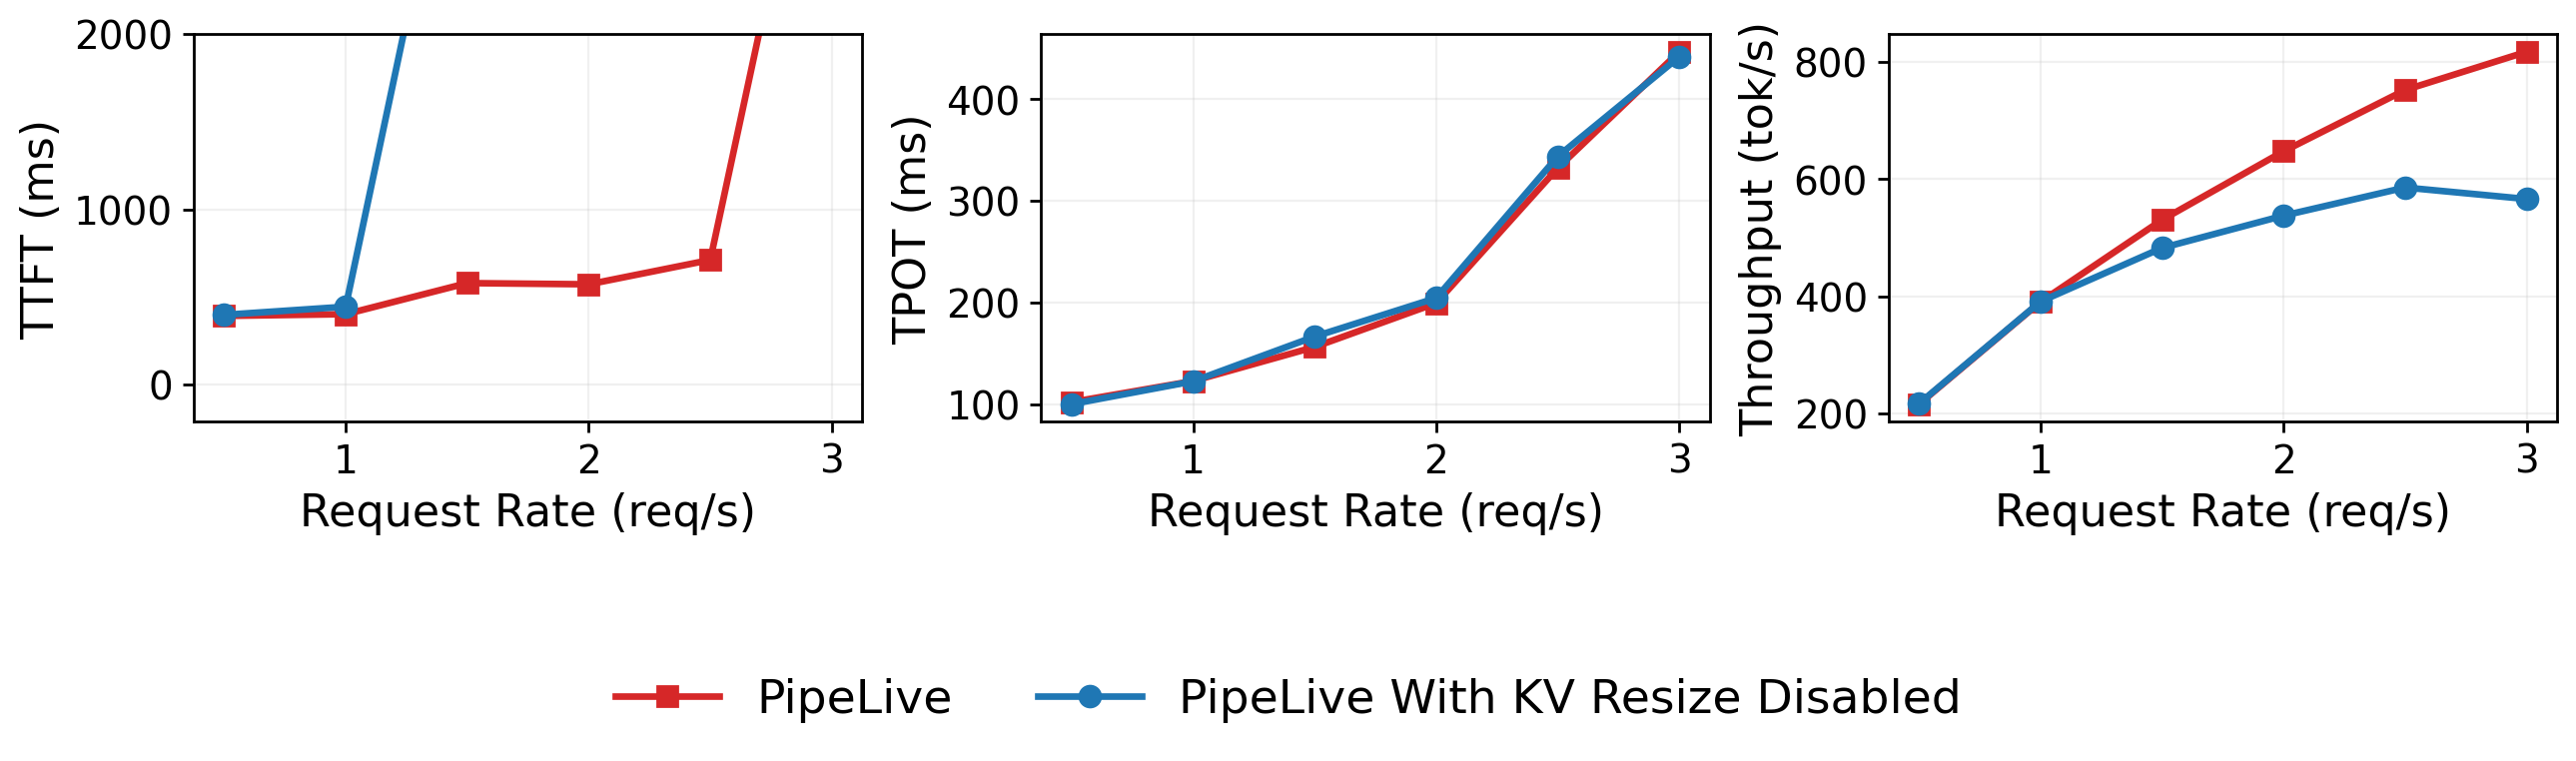

=== 从 benchmark.log 提取的聚合指标 ===
 rr                           resize  ttft_ms  tpot_ms  throughput_tok_s
0.5 PipeLive With KV Resize Disabled   396.68    99.92            216.76
0.5                         PipeLive   390.53   101.92            215.80
1.0 PipeLive With KV Resize Disabled   443.25   122.35            391.06
1.0                         PipeLive   400.52   122.63            390.47
1.5 PipeLive With KV Resize Disabled  3716.00   166.37            482.55
1.5                         PipeLive   578.02   156.14            530.46
2.0 PipeLive With KV Resize Disabled  5283.65   204.30            537.67
2.0                         PipeLive   571.14   199.28            647.59
2.5 PipeLive With KV Resize Disabled  7286.86   343.56            585.68
2.5                         PipeLive   710.29   332.16            752.17
3.0 PipeLive With KV Resize Disabled 12476.50   441.63            566.06
3.0                         PipeLive  3932.40   446.59            817.48


KeyError: ('ttft_ms', 'Pipeline With KV Resize Disabled')

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['figure.dpi'] = 200

BASE_DIR = Path('/home/bxb1/vllm_workbench/vllm/new-logs/project-resize-test-full')
OUTPUT_PREFIX = Path('/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/resize-rr-metrics')

DIR_PATTERN = re.compile(r'rr=(?P<rr>[0-9.]+).*?kv_resize=(?P<kv_resize>[01])')
METRIC_PATTERNS = {
    'total_throughput_tok_s': re.compile(
        r'TOTAL TOKEN THROUGHPUT \(tokens/s\):\s+Average:\s+(?P<value>[0-9.]+)',
        re.S,
    ),
    'ttft_ms': re.compile(
        r'MEAN TTFT ACROSS REPETITIONS \(ms\):\s+Average:\s+(?P<value>[0-9.]+)',
        re.S,
    ),
    'tpot_ms': re.compile(
        r'MEAN TPOT ACROSS REPETITIONS \(ms\):\s+Average:\s+(?P<value>[0-9.]+)',
        re.S,
    ),
}


def parse_folder_metadata(folder_name: str) -> dict[str, float | int] | None:
    match = DIR_PATTERN.search(folder_name)
    if match is None:
        return None
    return {
        'request_rate': float(match.group('rr')),
        'kv_resize': int(match.group('kv_resize')),
    }


def parse_benchmark_metrics(log_path: Path) -> dict[str, float]:
    text = log_path.read_text(encoding='utf-8')
    metrics: dict[str, float] = {}
    for metric_name, pattern in METRIC_PATTERNS.items():
        match = pattern.search(text)
        if match is None:
            raise ValueError(f'无法在 {log_path} 中找到指标 {metric_name}')
        metrics[metric_name] = float(match.group('value'))
    return metrics


records: list[dict[str, float | int | str]] = []
for test_dir in sorted(BASE_DIR.iterdir()):
    if not test_dir.is_dir():
        continue

    metadata = parse_folder_metadata(test_dir.name)
    if metadata is None:
        continue

    benchmark_log = test_dir / 'benchmark.log'
    if not benchmark_log.exists():
        continue

    try:
        metrics = parse_benchmark_metrics(benchmark_log)
    except ValueError as exc:
        print(f'跳过 {test_dir.name}: {exc}')
        continue

    records.append({
        'experiment': test_dir.name,
        **metadata,
        **metrics,
    })

if not records:
    raise RuntimeError(f'未在 {BASE_DIR} 中解析到任何 benchmark 指标')


df = pd.DataFrame(records).sort_values(['request_rate', 'kv_resize']).reset_index(drop=True)
df['kv_resize_label'] = df['kv_resize'].map({0: 'PipeLive With KV Resize Disabled', 1: 'PipeLive'})

plot_specs = [
    ('ttft_ms', 'TTFT (ms)'),
    ('tpot_ms', 'TPOT (ms)'),
    ('total_throughput_tok_s', 'Throughput (tok/s)'),
]

fig, axes = plt.subplots(1, 3, figsize=(13.0, 3.2), sharex=True)
colors = {'PipeLive': '#d62728', 'PipeLive With KV Resize Disabled': '#1f77b4'}
markers = {'PipeLive': 's', 'PipeLive With KV Resize Disabled': 'o'}

for ax, (metric_key, title) in zip(axes, plot_specs):
    table = df.pivot(index='request_rate', columns='kv_resize_label', values=metric_key)

    for label in ['PipeLive', 'PipeLive With KV Resize Disabled']:
        if label not in table.columns:
            continue
        ax.plot(
            table.index,
            table[label],
            marker=markers[label],
            linewidth=2.4,
            markersize=7.5,
            color=colors[label],
            label=label,
        )

    ax.set_xlabel('Request Rate (req/s)', fontsize=16)
    ax.set_ylabel(title, fontsize=16)
    ax.grid(True, linestyle='-', alpha=0.18, linewidth=0.8)
    ax.tick_params(axis='both', labelsize=14, width=1.0, length=4)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

    if metric_key == 'ttft_ms':
        ax.set_ylim(top=2000)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.01),
    ncol=2,
    frameon=False,
    fontsize=17,
    handlelength=2.2,
    columnspacing=1.8,
)
fig.tight_layout(rect=(0, 0.1, 1, 1))

plt.savefig(f'{OUTPUT_PREFIX}.pdf', bbox_inches='tight')
plt.savefig(f'{OUTPUT_PREFIX}.png', dpi=300, bbox_inches='tight')
plt.show()

summary = df[['request_rate', 'kv_resize_label', 'ttft_ms', 'tpot_ms', 'total_throughput_tok_s']].copy()
summary = summary.rename(columns={
    'request_rate': 'rr',
    'kv_resize_label': 'resize',
    'total_throughput_tok_s': 'throughput_tok_s',
})
print('=== 从 benchmark.log 提取的聚合指标 ===')
print(summary.to_string(index=False))

comparison = (
    df.pivot(index='request_rate', columns='kv_resize_label', values=['ttft_ms', 'tpot_ms', 'total_throughput_tok_s'])
    .sort_index()
)
comparison[('delta_pct', 'TTFT↓')] = (comparison[('ttft_ms', 'PipeLive')] - comparison[('ttft_ms', 'Pipeline With KV Resize Disabled')]) / comparison[('ttft_ms', 'Pipeline With KV Resize Disabled')] * 100
comparison[('delta_pct', 'TPOT↓')] = (comparison[('tpot_ms', 'PipeLive')] - comparison[('tpot_ms', 'Pipeline With KV Resize Disabled')]) / comparison[('tpot_ms', 'Pipeline With KV Resize Disabled')] * 100
comparison[('delta_pct', 'Throughput↑')] = (comparison[('total_throughput_tok_s', 'PipeLive')] - comparison[('total_throughput_tok_s', 'Pipeline With KV Resize Disabled')]) / comparison[('total_throughput_tok_s', 'Pipeline With KV Resize Disabled')] * 100

print('\n=== Resize On 相对 Resize Off 的变化百分比 ===')
print(
    comparison[[('delta_pct', 'TTFT↓'), ('delta_pct', 'TPOT↓'), ('delta_pct', 'Throughput↑')]]
    .round(2)
    .to_string()
)